## Block 0 — Setup and configuration

In [33]:
import os
import sys
import json
import time
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIELD_DIR    = PROJECT_ROOT / 'data' / 'field'
METADATA     = FIELD_DIR / 'trip_metadata.csv'
MODELS_DIR   = PROJECT_ROOT / 'models'
ONNX_PATH    = MODELS_DIR / 'onnx' / 'obd_stress_xgb.onnx'
OUTPUTS_DIR  = PROJECT_ROOT / 'outputs'

(OUTPUTS_DIR / 'data').mkdir(parents=True, exist_ok=True)
(OUTPUTS_DIR / 'plots').mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Field dir:    {FIELD_DIR}")
print(f"Metadata:     {METADATA}  ({'found' if METADATA.exists() else 'MISSING'})")
print(f"ONNX model:   {ONNX_PATH}  ({'found' if ONNX_PATH.exists() else 'MISSING'})")

if FIELD_DIR.exists():
    csv_files = sorted(FIELD_DIR.rglob('*.csv'))
    csv_files = [f for f in csv_files if f.name != 'trip_metadata.csv']
    print(f"\nTrip CSVs found ({len(csv_files)}):")
    for p in csv_files:
        print(f"  {p.relative_to(FIELD_DIR)}  ({p.stat().st_size / 1024 / 1024:.1f} MB)")

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
sns.set_palette('Set2')

VERDICT_NAMES  = ['Safe', 'Diagnostic', 'Do not drive']
VERDICT_COLORS = ['#10b981', '#f59e0b', '#dc2626']
CONDITION_COLORS = {
    'engine_off': '#94a3b8',
    'idle':       '#fcd34d',
    'slow':       '#fb923c',
    'city':       '#f87171',
    'arterial':   '#60a5fa',
    'highway':    '#34d399',
}

ONNX_FEATURES = [
    'ENGINE_RPM',
    'THROTTLE_POS',
    'ENGINE_COOLANT_TEMP',
    'ENGINE_LOAD',
    'SPEED',
    'INTAKE_MANIFOLD_PRESSURE',
]

print(f"\nONNX input features ({len(ONNX_FEATURES)}):")
for f in ONNX_FEATURES:
    print(f"  - {f}")

Project root: d:\stadiploma
Field dir:    d:\stadiploma\data\field
Metadata:     d:\stadiploma\data\field\trip_metadata.csv  (found)
ONNX model:   d:\stadiploma\models\onnx\obd_stress_xgb.onnx  (found)

Trip CSVs found (10):
  2026-05-16 13-44-51.csv  (16.0 MB)
  2026-05-17 13-13-36.csv  (8.1 MB)
  2026-05-22 09-23-55.csv  (1.8 MB)
  2026-05-22 16-49-59.csv  (5.9 MB)
  2026-05-23 10-22-40.csv  (2.6 MB)
  2026-05-23 13-09-34.csv  (3.3 MB)
  2026-05-25 15-47-50.csv  (4.2 MB)
  2026-05-26 00-21-38.csv  (2.0 MB)
  2026-05-27 21-36-39.csv  (2.9 MB)
  2026-05-27 23-32-36.csv  (3.0 MB)

ONNX input features (6):
  - ENGINE_RPM
  - THROTTLE_POS
  - ENGINE_COOLANT_TEMP
  - ENGINE_LOAD
  - SPEED
  - INTAKE_MANIFOLD_PRESSURE


## Block 1 — Russian → standard column mapping

In [34]:
COLUMN_MAP = {
    'time':       'time_str',
    'Latitude':   'lat',
    'Longtitude': 'lng',
    'Высота (GPS) (m)':       'gps_altitude',
    'Скорость (GPS) (km/h)':  'gps_speed',

    'Обороты двигателя (rpm)':                          'ENGINE_RPM',
    'Скорость автомобиля (km/h)':                       'SPEED',
    'Температура охлаждающей жидкости (℃)':             'ENGINE_COOLANT_TEMP',
    'Положение дроссельной заслонки (%)':               'THROTTLE_POS',
    'Расчетное значение нагрузки на двигатель (%)':     'ENGINE_LOAD',
    'Температура всасываемого воздуха (℃)':             'INTAKE_AIR_TEMP',
    'Давление во впускном коллекторе (абсолютное) (kPa)': 'INTAKE_MANIFOLD_PRESSURE',
    'Угол опережения зажигания (°)':                    'TIMING_ADVANCE',
    'Положение педали акселератора D (%)':              'ACCEL_PEDAL_D',

    'Кратковременная коррекция - Блок 1 (%)':           'STFT_B1',
    'Долговременная коррекция - Блок 1 (%)':            'LTFT_B1',
    'Соотношение топливо/воздух ()':                    'AIR_FUEL_RATIO',
    'Датчик кислорода 2 Блок 1 Напряжение (V)':         'O2_VOLTAGE_B1S2',
    'Температура катализатора Датчик 1 Блок 1 (℃)':     'CAT_TEMP_B1S1',
    'Датчик кислорода 1 (широкополосный) Коррекция соотношения топливовоздушной смеси ()': 'WIDEBAND_O2_CORRECTION',

    'Напряжение (ELM327) (V)':                          'BATTERY_VOLTAGE',
    'Атмосферное давление (абсолютное) (kPa)':          'BAROMETRIC_PRESSURE',
    'Температура окружающего воздуха (℃)':              'AMBIENT_AIR_TEMP',

    '[ECM] Температура масла в CVVT (℃)':               'ENGINE_OIL_TEMP',
    '[TCM] Температура АКПП (℃)':                       'TRANSMISSION_TEMP',
    '[TCM] Текущая передача ()':                        'CURRENT_GEAR',
    '[TCM] Проскальзывание гидротрансформатора (rpm)':  'TC_SLIP',
    '[TCM] Педаль тормоза ()':                          'BRAKE_PEDAL',
    '[TCM] Скорость выходного вала (rpm)':              'TC_OUTPUT_SHAFT',

    '[AWD] Скорость переднего правого колеса (km/h)':   'WHEEL_FR',
    '[AWD] Скорость переднего левого колеса (km/h)':    'WHEEL_FL',
    '[AWD] Скорость заднего правого колеса (km/h)':     'WHEEL_RR',
    '[AWD] Скорость заднего левого колеса (km/h)':      'WHEEL_RL',
    '[AWD] Угол поворота руля (°)':                     'STEERING_ANGLE',
    '[AWD] Заданный крутящий момент (N⋅m)':             'AWD_TORQUE',
    '[AWD] Заданная степень сцепления муфты (%)':       'AWD_CLUTCH',

    'Ускорение (g)':                                    'ACCELERATION',
}

print(f"COLUMN_MAP defines {len(COLUMN_MAP)} Russian → standard mappings")
sensor_count = sum(1 for v in COLUMN_MAP.values() if v not in ('time_str', 'lat', 'lng', 'gps_altitude', 'gps_speed'))
print(f"Sensor PIDs: {sensor_count}  (+ time + lat/lng + gps_altitude + gps_speed)")

COLUMN_MAP defines 37 Russian → standard mappings
Sensor PIDs: 32  (+ time + lat/lng + gps_altitude + gps_speed)


## Block 2 — Parse Car Scanner CSVs

In [35]:
def parse_trip_csv(csv_path):
    """Parse one Car Scanner CSV → DataFrame indexed by datetime, standardized columns.
    Accepts two filename formats:
      • '2026-05-16 13-44-51.csv'  (original — spaces and dashes)
      • '20260522_092355.csv'      (compact CarScanner export)
    Both normalize to trip_id '2026-MM-DD_HH-MM-SS'.
    """
    import re
    path = Path(csv_path)
    stem = path.stem
    m = re.match(r'^(\d{4})(\d{2})(\d{2})_(\d{2})(\d{2})(\d{2})$', stem)
    if m:
        trip_id  = f"{m[1]}-{m[2]}-{m[3]}_{m[4]}-{m[5]}-{m[6]}"
        date_str = f"{m[1]}-{m[2]}-{m[3]}"
    else:
        trip_id  = stem.replace(' ', '_')
        date_str = trip_id[:10]

    raw = pd.read_csv(path, low_memory=False)

    raw['datetime'] = pd.to_datetime(
        date_str + ' ' + raw['time'].astype(str),
        format='%Y-%m-%d %H:%M:%S.%f',
        errors='coerce',
    )

    # Handle midnight rollover: if time wraps (e.g. 23:59 -> 00:01),
    # add +1 day to all rows after each wrap. cumsum supports multi-day trips.
    if raw['datetime'].notna().sum() > 1:
        time_diff = raw['datetime'].diff()
        days_offset = (time_diff < pd.Timedelta(0)).cumsum()
        raw['datetime'] = raw['datetime'] + pd.to_timedelta(days_offset, unit='D')

    # Drop rows where datetime parsing failed (NaT) — Car Scanner sometimes
    # exports partial trailing rows or empty time cells which become NaT.
    before = len(raw)
    raw = raw.dropna(subset=['datetime'])
    dropped = before - len(raw)
    if dropped > 0:
        print(f"  ⚠ {trip_id}: dropped {dropped:,} rows with invalid time")

    if raw.empty:
        return pd.DataFrame()

    keep = {old: new for old, new in COLUMN_MAP.items() if old in raw.columns}
    df = raw[['datetime'] + list(keep.keys())].rename(columns=keep)
    df = df.drop(columns=['time_str'], errors='ignore')
    df['trip_id'] = trip_id

    return df.set_index('datetime').sort_index()

csv_paths = sorted(FIELD_DIR.rglob('*.csv'))
csv_paths = [p for p in csv_paths if p.name != 'trip_metadata.csv']
print(f"Parsing {len(csv_paths)} trip CSV(s):\n")

trips_raw = {}
t0 = time.time()
for csv_path in csv_paths:
    df = parse_trip_csv(csv_path)
    if df.empty:
        print(f"  ✗ {csv_path.name}: empty after parsing, skipped")
        continue
    trip_id = df['trip_id'].iloc[0]
    trips_raw[trip_id] = df
    duration_min = (df.index.max() - df.index.min()).total_seconds() / 60
    pid_count = len(df.columns) - 1
    print(f"  ✓ {trip_id:25}  rows: {len(df):>7,}  cols: {pid_count:>2}  duration: {duration_min:>6.1f} min")

print(f"\nParsed {len(trips_raw)} valid trip(s) in {time.time()-t0:.1f} sec")

Parsing 10 trip CSV(s):

  ✓ 2026-05-16_13-44-51        rows:  81,624  cols: 36  duration:  155.3 min
  ✓ 2026-05-17_13-13-36        rows:  52,989  cols: 35  duration:  138.6 min
  ✓ 2026-05-22_09-23-55        rows:  12,692  cols: 31  duration:   31.0 min
  ✓ 2026-05-22_16-49-59        rows:  45,745  cols: 31  duration:   99.4 min
  ✓ 2026-05-23_10-22-40        rows:  18,637  cols: 31  duration:   52.1 min
  ✓ 2026-05-23_13-09-34        rows:  25,413  cols: 31  duration:   54.7 min
  ✓ 2026-05-25_15-47-50        rows:  32,290  cols: 31  duration:   80.5 min
  ✓ 2026-05-26_00-21-38        rows:  12,997  cols: 36  duration:   25.6 min
  ✓ 2026-05-27_21-36-39        rows:  18,781  cols: 36  duration:   65.8 min
  ✓ 2026-05-27_23-32-36        rows:  19,383  cols: 36  duration:   28.0 min

Parsed 10 valid trip(s) in 1.9 sec


## Block 3 — Resample sparse polling to 1 Hz

In [36]:
def resample_to_1hz(df, ffill_limit_s=30):
    """Resample to 1 Hz via last-in-bucket, forward-fill capped at ffill_limit_s seconds."""
    if df.empty or df.index.isna().all():
        return df
    trip_id = df['trip_id'].iloc[0]
    numeric = df.select_dtypes(include=[np.number])
    rs = numeric.resample('1s').last().ffill(limit=ffill_limit_s)
    rs['trip_id'] = trip_id
    return rs

trips_1hz = {}
print(f"Resampling {len(trips_raw)} trip(s) to 1 Hz with ffill_limit=30s:\n")
print(f"{'trip_id':25}  {'raw rows':>10}  {'1Hz rows':>10}  {'compression':>12}")
print(f"{'-' * 25}  {'-' * 10}  {'-' * 10}  {'-' * 12}")

for trip_id, df in trips_raw.items():
    df_1hz = resample_to_1hz(df)
    if df_1hz.empty:
        print(f"  ✗ {trip_id:23}  empty after resample, skipped")
        continue
    trips_1hz[trip_id] = df_1hz
    compression = len(df) / len(df_1hz)
    print(f"  ✓ {trip_id:23}  {len(df):>10,}  {len(df_1hz):>10,}  {compression:>10.1f}x")

total_1hz = sum(len(d) for d in trips_1hz.values())
print(f"\nTotal 1Hz samples across all trips: {total_1hz:,}")

Resampling 10 trip(s) to 1 Hz with ffill_limit=30s:

trip_id                      raw rows    1Hz rows   compression
-------------------------  ----------  ----------  ------------
  ✓ 2026-05-16_13-44-51          81,624       9,321         8.8x
  ✓ 2026-05-17_13-13-36          52,989       8,314         6.4x
  ✓ 2026-05-22_09-23-55          12,692       1,859         6.8x
  ✓ 2026-05-22_16-49-59          45,745       5,965         7.7x
  ✓ 2026-05-23_10-22-40          18,637       3,129         6.0x
  ✓ 2026-05-23_13-09-34          25,413       3,281         7.7x
  ✓ 2026-05-25_15-47-50          32,290       4,830         6.7x
  ✓ 2026-05-26_00-21-38          12,997       1,538         8.5x
  ✓ 2026-05-27_21-36-39          18,781       3,949         4.8x
  ✓ 2026-05-27_23-32-36          19,383       1,683        11.5x

Total 1Hz samples across all trips: 43,869


## Block 4 — Compile trip metadata from raw + annotations

In [37]:
TRIP_ANNOTATIONS = {
    '2026-05-16_13-44-51': {
        'vehicle':    'Hyundai Tucson',
        'subjective': 'normal',
        'notes':      'Astana → Karaganda; first long highway test',
    },
    '2026-05-17_13-13-36': {
        'vehicle':    'Hyundai Tucson',
        'subjective': 'normal',
        'notes':      'similar highway route; GPS lost mid-trip',
    },
    '2026-05-22_09-23-55': {
        'vehicle':    'Hyundai Tucson',
        'subjective': 'normal',
        'notes':      'morning drive (~31 min)',
    },
    '2026-05-22_16-49-59': {
        'vehicle':    'Hyundai Tucson',
        'subjective': 'normal',
        'notes':      'evening drive, longer route (~99 min)',
    },
    '2026-05-23_10-22-40': {
        'vehicle':    'Hyundai Tucson',
        'subjective': 'normal',
        'notes':      'morning drive (~52 min)',
    },
    '2026-05-23_13-09-34': {
        'vehicle':    'Hyundai Tucson',
        'subjective': 'normal',
        'notes':      'midday drive (~55 min)',
    },
    '2026-05-25_15-47-50': {
        'vehicle':    'Hyundai Tucson',
        'subjective': 'normal',
        'notes':      'afternoon drive (~80 min)',
    },
    '2026-05-26_00-21-38': {
        'vehicle':    'Hyundai Tucson',
        'subjective': 'normal',
        'notes':      'late-night drive (~26 min)',
    },
    '2026-05-27_21-36-39': {
        'vehicle':    'Hyundai Tucson',
        'subjective': 'normal',
        'notes':      'evening drive (~66 min)',
    },
    '2026-05-27_23-32-36': {
        'vehicle':    'Hyundai Tucson',
        'subjective': 'normal',
        'notes':      'late-night drive (~28 min)',
    },
}

def classify_trip_overall(df):
    """High-level trip label from speed distribution."""
    if 'SPEED' not in df.columns or df['SPEED'].notna().sum() == 0:
        return 'unknown'
    speed = df['SPEED'].dropna()
    pct_highway = (speed >= 60).mean() * 100
    pct_idle    = (speed < 5).mean() * 100
    if pct_idle > 80:    return 'idle'
    if pct_highway > 60: return 'highway'
    if pct_highway > 25: return 'mixed'
    return 'city'

def compile_metadata(trips_raw, annotations):
    """Compile trip metadata: auto-derive from CSV, merge with manual annotations."""
    rows = []
    for trip_id, df in trips_raw.items():
        valid = df.dropna(how='all')
        date_str = trip_id[:10]
        start_time = valid.index.min()
        end_time   = valid.index.max()
        duration_min = round((end_time - start_time).total_seconds() / 60, 1)
        conditions = classify_trip_overall(df)

        ann = annotations.get(trip_id, {})
        if not ann:
            print(f"\n  {'─' * 64}")
            print(f"  ⚠ NEW TRIP — paste into TRIP_ANNOTATIONS dict in Block 4:")
            print(f"")
            print(f"      '{trip_id}': {{")
            print(f"          'driver':     '',")
            print(f"          'vehicle':    '',")
            print(f"          'subjective': '',")
            print(f"          'notes':      '',")
            print(f"      }},")
            print(f"  {'─' * 64}\n")

        rows.append({
            'trip_id':       trip_id,
            'date':          date_str,
            'driver':        ann.get('driver', ''),
            'vehicle':       ann.get('vehicle', ''),
            'start_time':    start_time.strftime('%H:%M:%S'),
            'end_time':      end_time.strftime('%H:%M:%S'),
            'duration_min':  duration_min,
            'conditions':    conditions,
            'subjective':    ann.get('subjective', ''),
            'notes':         ann.get('notes', ''),
        })
    return pd.DataFrame(rows)

metadata = compile_metadata(trips_raw, TRIP_ANNOTATIONS)

print(f"Compiled metadata for {len(metadata)} trip(s):\n")
print(metadata.to_string(index=False))

metadata.to_csv(METADATA, index=False)
print(f"\nSaved: {METADATA.relative_to(PROJECT_ROOT)}  ({METADATA.stat().st_size / 1024:.1f} KB)")

Compiled metadata for 10 trip(s):

            trip_id       date driver        vehicle start_time end_time  duration_min conditions subjective                                       notes
2026-05-16_13-44-51 2026-05-16        Hyundai Tucson   13:44:57 16:20:17         155.3    highway     normal Astana → Karaganda; first long highway test
2026-05-17_13-13-36 2026-05-17        Hyundai Tucson   13:13:36 15:32:09         138.6    highway     normal    similar highway route; GPS lost mid-trip
2026-05-22_09-23-55 2026-05-22        Hyundai Tucson   09:24:03 09:55:01          31.0       city     normal                     morning drive (~31 min)
2026-05-22_16-49-59 2026-05-22        Hyundai Tucson   16:50:09 18:29:33          99.4    highway     normal       evening drive, longer route (~99 min)
2026-05-23_10-22-40 2026-05-23        Hyundai Tucson   10:22:48 11:14:56          52.1      mixed     normal                     morning drive (~52 min)
2026-05-23_13-09-34 2026-05-23        Hyundai T

## Block 5 — Per-trip descriptive statistics

In [38]:
def compute_trip_summary(df, trip_id, metadata):
    """One-row summary per trip with metadata join."""
    row = {'trip_id': trip_id}

    meta = metadata[metadata['trip_id'] == trip_id]
    if not meta.empty:
        row['driver']     = meta.iloc[0].get('driver', '')
        row['conditions'] = meta.iloc[0].get('conditions', '')
        row['subjective'] = meta.iloc[0].get('subjective', '')

    valid = df.dropna(how='all')
    row['duration_min'] = round((valid.index.max() - valid.index.min()).total_seconds() / 60, 1)
    row['samples_1hz']  = len(valid)

    def stat(col, fn):
        if col in df.columns and df[col].notna().any():
            return round(float(fn(df[col].dropna())), 1)
        return None

    row['rpm_max']      = stat('ENGINE_RPM',          np.max)
    row['rpm_mean']     = stat('ENGINE_RPM',          np.mean)
    row['speed_max']    = stat('SPEED',               np.max)
    row['speed_mean']   = stat('SPEED',               np.mean)
    row['load_mean']    = stat('ENGINE_LOAD',         np.mean)
    row['coolant_max']  = stat('ENGINE_COOLANT_TEMP', np.max)
    row['oil_max']      = stat('ENGINE_OIL_TEMP',     np.max)
    row['atf_max']      = stat('TRANSMISSION_TEMP',   np.max)
    row['stft_max']     = stat('STFT_B1',             np.max)
    row['ltft_max']     = stat('LTFT_B1',             np.max)
    return row

summary_rows = [compute_trip_summary(trips_1hz[tid], tid, metadata) for tid in trips_1hz]
summary_df = pd.DataFrame(summary_rows).set_index('trip_id')

print(f"Per-trip summary ({len(summary_df)} trips):\n")
print(summary_df.to_string())

Per-trip summary (10 trips):

                    driver conditions subjective  duration_min  samples_1hz  rpm_max  rpm_mean  speed_max  speed_mean  load_mean  coolant_max  oil_max  atf_max  stft_max  ltft_max
trip_id                                                                                                                                                                            
2026-05-16_13-44-51           highway     normal         155.3         9321   3666.0    2250.5      155.0        90.1       70.6         96.0    101.2     98.0      13.3       4.7
2026-05-17_13-13-36           highway     normal         138.6         8314   3378.0    2191.5      150.0        86.0       68.1         96.0    101.2     98.0      15.6       7.0
2026-05-22_09-23-55              city     normal          31.0         1859   2545.0    1165.0       63.0        16.0       43.0         94.0     89.2     62.0       6.2       3.1
2026-05-22_16-49-59           highway     normal          99.4        

## Block 6 — Driving conditions classification

Driving conditions breakdown (% of trip):

                     engine_off  idle  slow  city  arterial  highway
trip_id                                                             
2026-05-16_13-44-51         0.0   8.6   5.7   9.8      22.7     53.3
2026-05-17_13-13-36         8.8   6.1   6.5  17.2      16.0     45.3
2026-05-22_09-23-55         1.0  49.6  21.5  26.9       1.0      0.0
2026-05-22_16-49-59         0.4   3.1   4.1  12.5      24.2     55.7
2026-05-23_10-22-40         7.9   7.1   9.5  34.0      36.3      5.2
2026-05-23_13-09-34         0.7  12.8  11.1  39.2      33.0      3.2
2026-05-25_15-47-50         0.0  10.1   8.1  32.0      38.5     11.3
2026-05-26_00-21-38         0.2  28.0  25.4  46.4       0.0      0.0
2026-05-27_21-36-39        38.2  21.9  10.0  29.3       0.6      0.0
2026-05-27_23-32-36         0.3  42.7  20.9  35.7       0.5      0.0


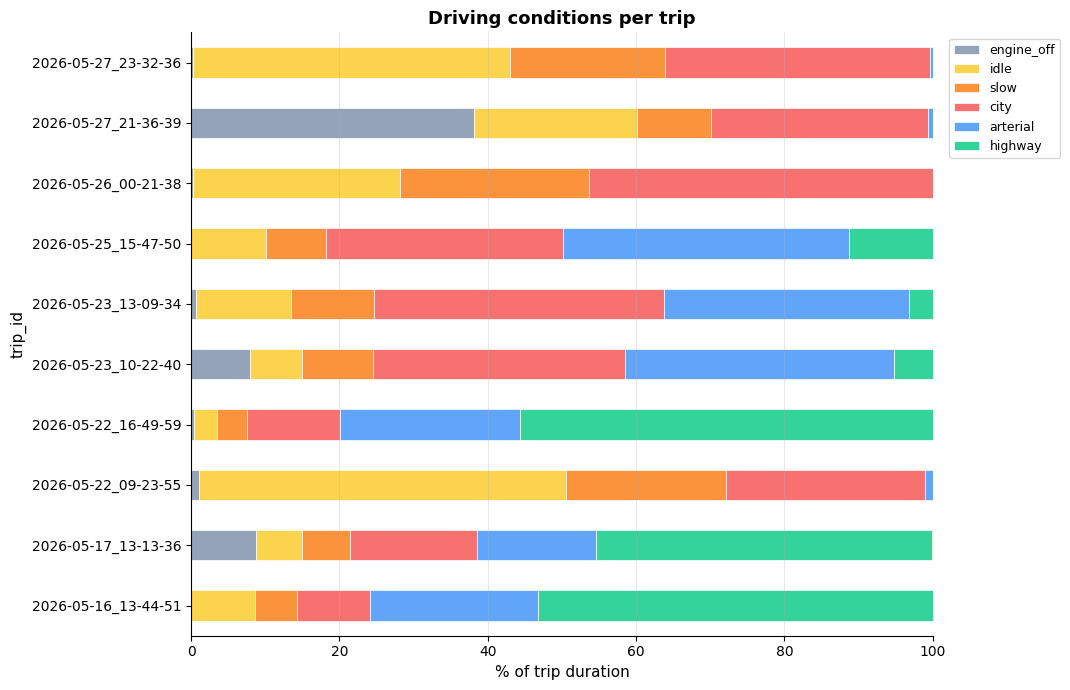

In [39]:
def classify_conditions(df):
    """Per-row driving condition label from RPM and speed."""
    rpm   = df.get('ENGINE_RPM', pd.Series(index=df.index, dtype=float))
    speed = df.get('SPEED',      pd.Series(index=df.index, dtype=float))

    cond = pd.Series('unknown', index=df.index, dtype=object)
    cond[(rpm.isna()) | (rpm < 300)]    = 'engine_off'
    cond[(rpm >= 300) & (speed < 5)]    = 'idle'
    cond[(speed >= 5)  & (speed < 30)]  = 'slow'
    cond[(speed >= 30) & (speed < 60)]  = 'city'
    cond[(speed >= 60) & (speed < 90)]  = 'arterial'
    cond[speed >= 90]                   = 'highway'
    return cond

cond_breakdown = []
for trip_id, df in trips_1hz.items():
    cond = classify_conditions(df)
    pct = cond.value_counts(normalize=True) * 100
    row = {'trip_id': trip_id}
    for c in ['engine_off', 'idle', 'slow', 'city', 'arterial', 'highway']:
        row[c] = round(pct.get(c, 0), 1)
    cond_breakdown.append(row)

cond_df = pd.DataFrame(cond_breakdown).set_index('trip_id')
print(f"Driving conditions breakdown (% of trip):\n")
print(cond_df.to_string())

fig, ax = plt.subplots(figsize=(11, max(3, 0.5 * len(cond_df) + 2)))
cond_df[['engine_off', 'idle', 'slow', 'city', 'arterial', 'highway']].plot(
    kind='barh', stacked=True, ax=ax,
    color=[CONDITION_COLORS[c] for c in ['engine_off', 'idle', 'slow', 'city', 'arterial', 'highway']],
    edgecolor='white', linewidth=0.5,
)
ax.set_xlabel('% of trip duration')
ax.set_xlim(0, 100)
ax.set_title('Driving conditions per trip', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.18, 1), fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'field_01_conditions_per_trip.png', bbox_inches='tight', dpi=120)
plt.show()

## Block 7 — Thermal profiles (coolant / oil / ATF)

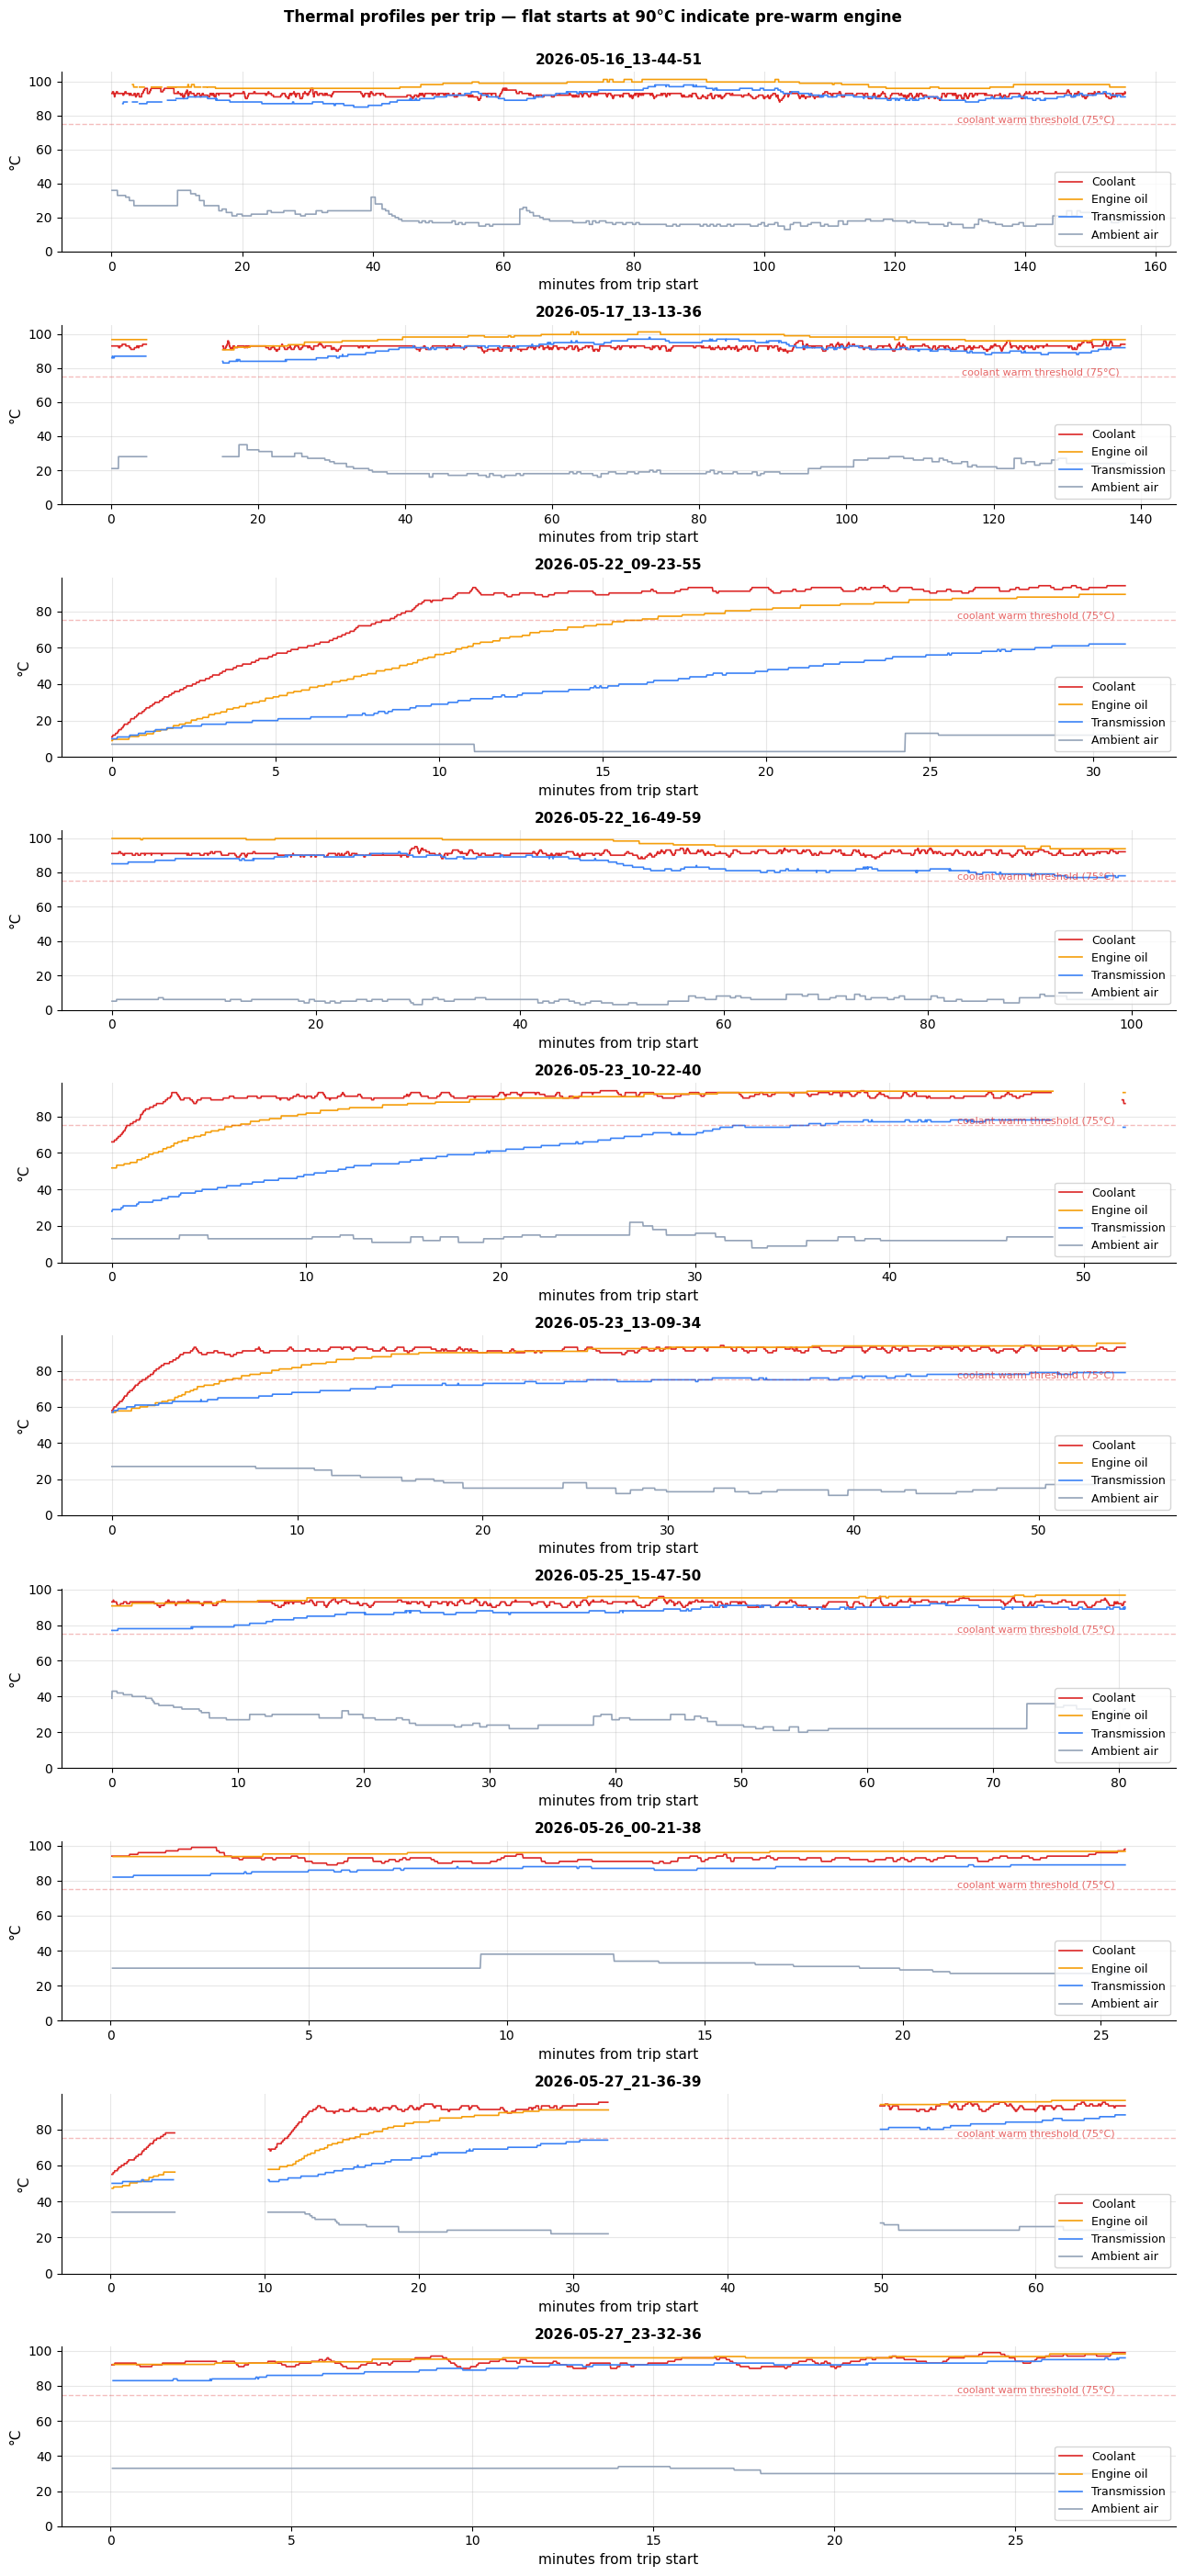

In [40]:
n_trips = len(trips_1hz)
fig, axes = plt.subplots(n_trips, 1, figsize=(13, 2.8 * n_trips), sharex=False)
if n_trips == 1:
    axes = [axes]

for ax, (trip_id, df) in zip(axes, trips_1hz.items()):
    t0_trip = df.dropna(how='all').index.min()
    rel_min = (df.index - t0_trip).total_seconds() / 60

    for col, label, color in [
        ('ENGINE_COOLANT_TEMP', 'Coolant',      '#dc2626'),
        ('ENGINE_OIL_TEMP',    'Engine oil',    '#f59e0b'),
        ('TRANSMISSION_TEMP',  'Transmission',  '#3b82f6'),
        ('AMBIENT_AIR_TEMP',   'Ambient air',   '#94a3b8'),
    ]:
        if col in df.columns and df[col].notna().any():
            ax.plot(rel_min, df[col], label=label, color=color, linewidth=1.2)

    ax.axhline(75, color='#dc2626', linestyle='--', alpha=0.3, linewidth=1)
    ax.text(rel_min.max() * 0.99, 76, 'coolant warm threshold (75°C)',
            fontsize=8, color='#dc2626', alpha=0.7, ha='right')

    ax.set_title(trip_id, fontsize=11, fontweight='bold')
    ax.set_ylabel('°C')
    ax.set_xlabel('minutes from trip start')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

plt.suptitle('Thermal profiles per trip — flat starts at 90°C indicate pre-warm engine',
             fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'field_02_thermal_profiles.png', bbox_inches='tight', dpi=120)
plt.show()

## Block 8 — ONNX inference on field data

In [41]:
import onnxruntime as ort

assert ONNX_PATH.exists(), f"ONNX model not found at {ONNX_PATH}. Run Notebook 03 first."

session = ort.InferenceSession(str(ONNX_PATH), providers=['CPUExecutionProvider'])
input_name = session.get_inputs()[0].name

print(f"Loaded: {ONNX_PATH.name}  ({ONNX_PATH.stat().st_size / 1024:.1f} KB)")
print(f"\nModel inputs:")
for i in session.get_inputs():
    print(f"  {i.name}  shape: {i.shape}  type: {i.type}")
print(f"\nModel outputs:")
for o in session.get_outputs():
    print(f"  {o.name}  shape: {o.shape}  type: {o.type}")

Loaded: obd_stress_xgb.onnx  (508.9 KB)

Model inputs:
  float_input  shape: [None, 6]  type: tensor(float)

Model outputs:
  label  shape: [None]  type: tensor(int64)
  probabilities  shape: [None, 3]  type: tensor(float)


In [42]:
def run_inference(df_1hz, session, feature_names):
    """Run ONNX model on rows where all required features are non-null."""
    feats = df_1hz[feature_names].dropna()
    if feats.empty:
        return pd.DataFrame()

    X = feats.values.astype(np.float32)
    outputs = session.run(None, {input_name: X})

    proba = None
    for out in outputs:
        if isinstance(out, np.ndarray) and out.ndim == 2 and out.shape[1] == 3:
            proba = out
            break

    if proba is None:
        return pd.DataFrame()

    pred = pd.DataFrame(proba, index=feats.index,
                        columns=['p_normal', 'p_diagnostic', 'p_critical'])
    pred['risk'] = 0.5 * pred['p_diagnostic'] + 1.0 * pred['p_critical']
    pred['verdict'] = pd.cut(
        pred['risk'],
        bins=[-0.01, 0.30, 0.65, 1.01],
        labels=['safe', 'diagnostic', 'do_not_drive'],
    )
    return pred

predictions = {}
print(f"Running inference on {len(trips_1hz)} trip(s):\n")
print(f"{'trip_id':25}  {'scored':>8}  {'safe':>7}  {'diag':>7}  {'do_not_drive':>14}  {'mean_risk':>10}")
print(f"{'-' * 25}  {'-' * 8}  {'-' * 7}  {'-' * 7}  {'-' * 14}  {'-' * 10}")

t0 = time.time()
for trip_id, df in trips_1hz.items():
    pred = run_inference(df, session, ONNX_FEATURES)
    predictions[trip_id] = pred
    if pred.empty:
        print(f"  {trip_id:23}  empty (missing required features)")
        continue
    v = pred['verdict'].value_counts(normalize=True) * 100
    print(f"  {trip_id:23}  {len(pred):>8,}  "
          f"{v.get('safe', 0):>6.1f}%  {v.get('diagnostic', 0):>6.1f}%  "
          f"{v.get('do_not_drive', 0):>13.1f}%  {pred['risk'].mean():>10.3f}")

print(f"\nInference completed in {time.time()-t0:.1f} sec")

Running inference on 10 trip(s):

trip_id                      scored     safe     diag    do_not_drive   mean_risk
-------------------------  --------  -------  -------  --------------  ----------
  2026-05-16_13-44-51         9,318     0.0%    31.5%           68.5%       0.841
  2026-05-17_13-13-36         7,639     0.0%    39.8%           60.2%       0.799
  2026-05-22_09-23-55         1,859    28.7%    64.4%            6.8%       0.391
  2026-05-22_16-49-59         5,963     0.0%    35.2%           64.8%       0.822
  2026-05-23_10-22-40         2,909     3.4%    70.3%           26.3%       0.611
  2026-05-23_13-09-34         3,281     3.7%    69.2%           27.2%       0.613
  2026-05-25_15-47-50         4,830     0.0%    69.1%           30.9%       0.651
  2026-05-26_00-21-38         1,535     0.0%    79.7%           20.3%       0.601
  2026-05-27_21-36-39         2,519    12.1%    73.8%           14.2%       0.509
  2026-05-27_23-32-36         1,680     0.0%    59.4%           

## Block 9 — Trip-level risk aggregation and timeline

Trip-level risk aggregation:

                     n_scored  risk_mean  risk_median  risk_max  pct_safe  pct_diagnostic  pct_do_not_drive
trip_id                                                                                                    
2026-05-16_13-44-51      9318      0.841        1.000       1.0       0.0            31.5              68.5
2026-05-17_13-13-36      7639      0.799        0.999       1.0       0.0            39.8              60.2
2026-05-22_09-23-55      1859      0.391        0.500       1.0      28.7            64.4               6.8
2026-05-22_16-49-59      5963      0.822        0.999       1.0       0.0            35.2              64.8
2026-05-23_10-22-40      2909      0.611        0.500       1.0       3.4            70.3              26.3
2026-05-23_13-09-34      3281      0.613        0.500       1.0       3.7            69.2              27.2
2026-05-25_15-47-50      4830      0.651        0.500       1.0       0.0            69.1              30.

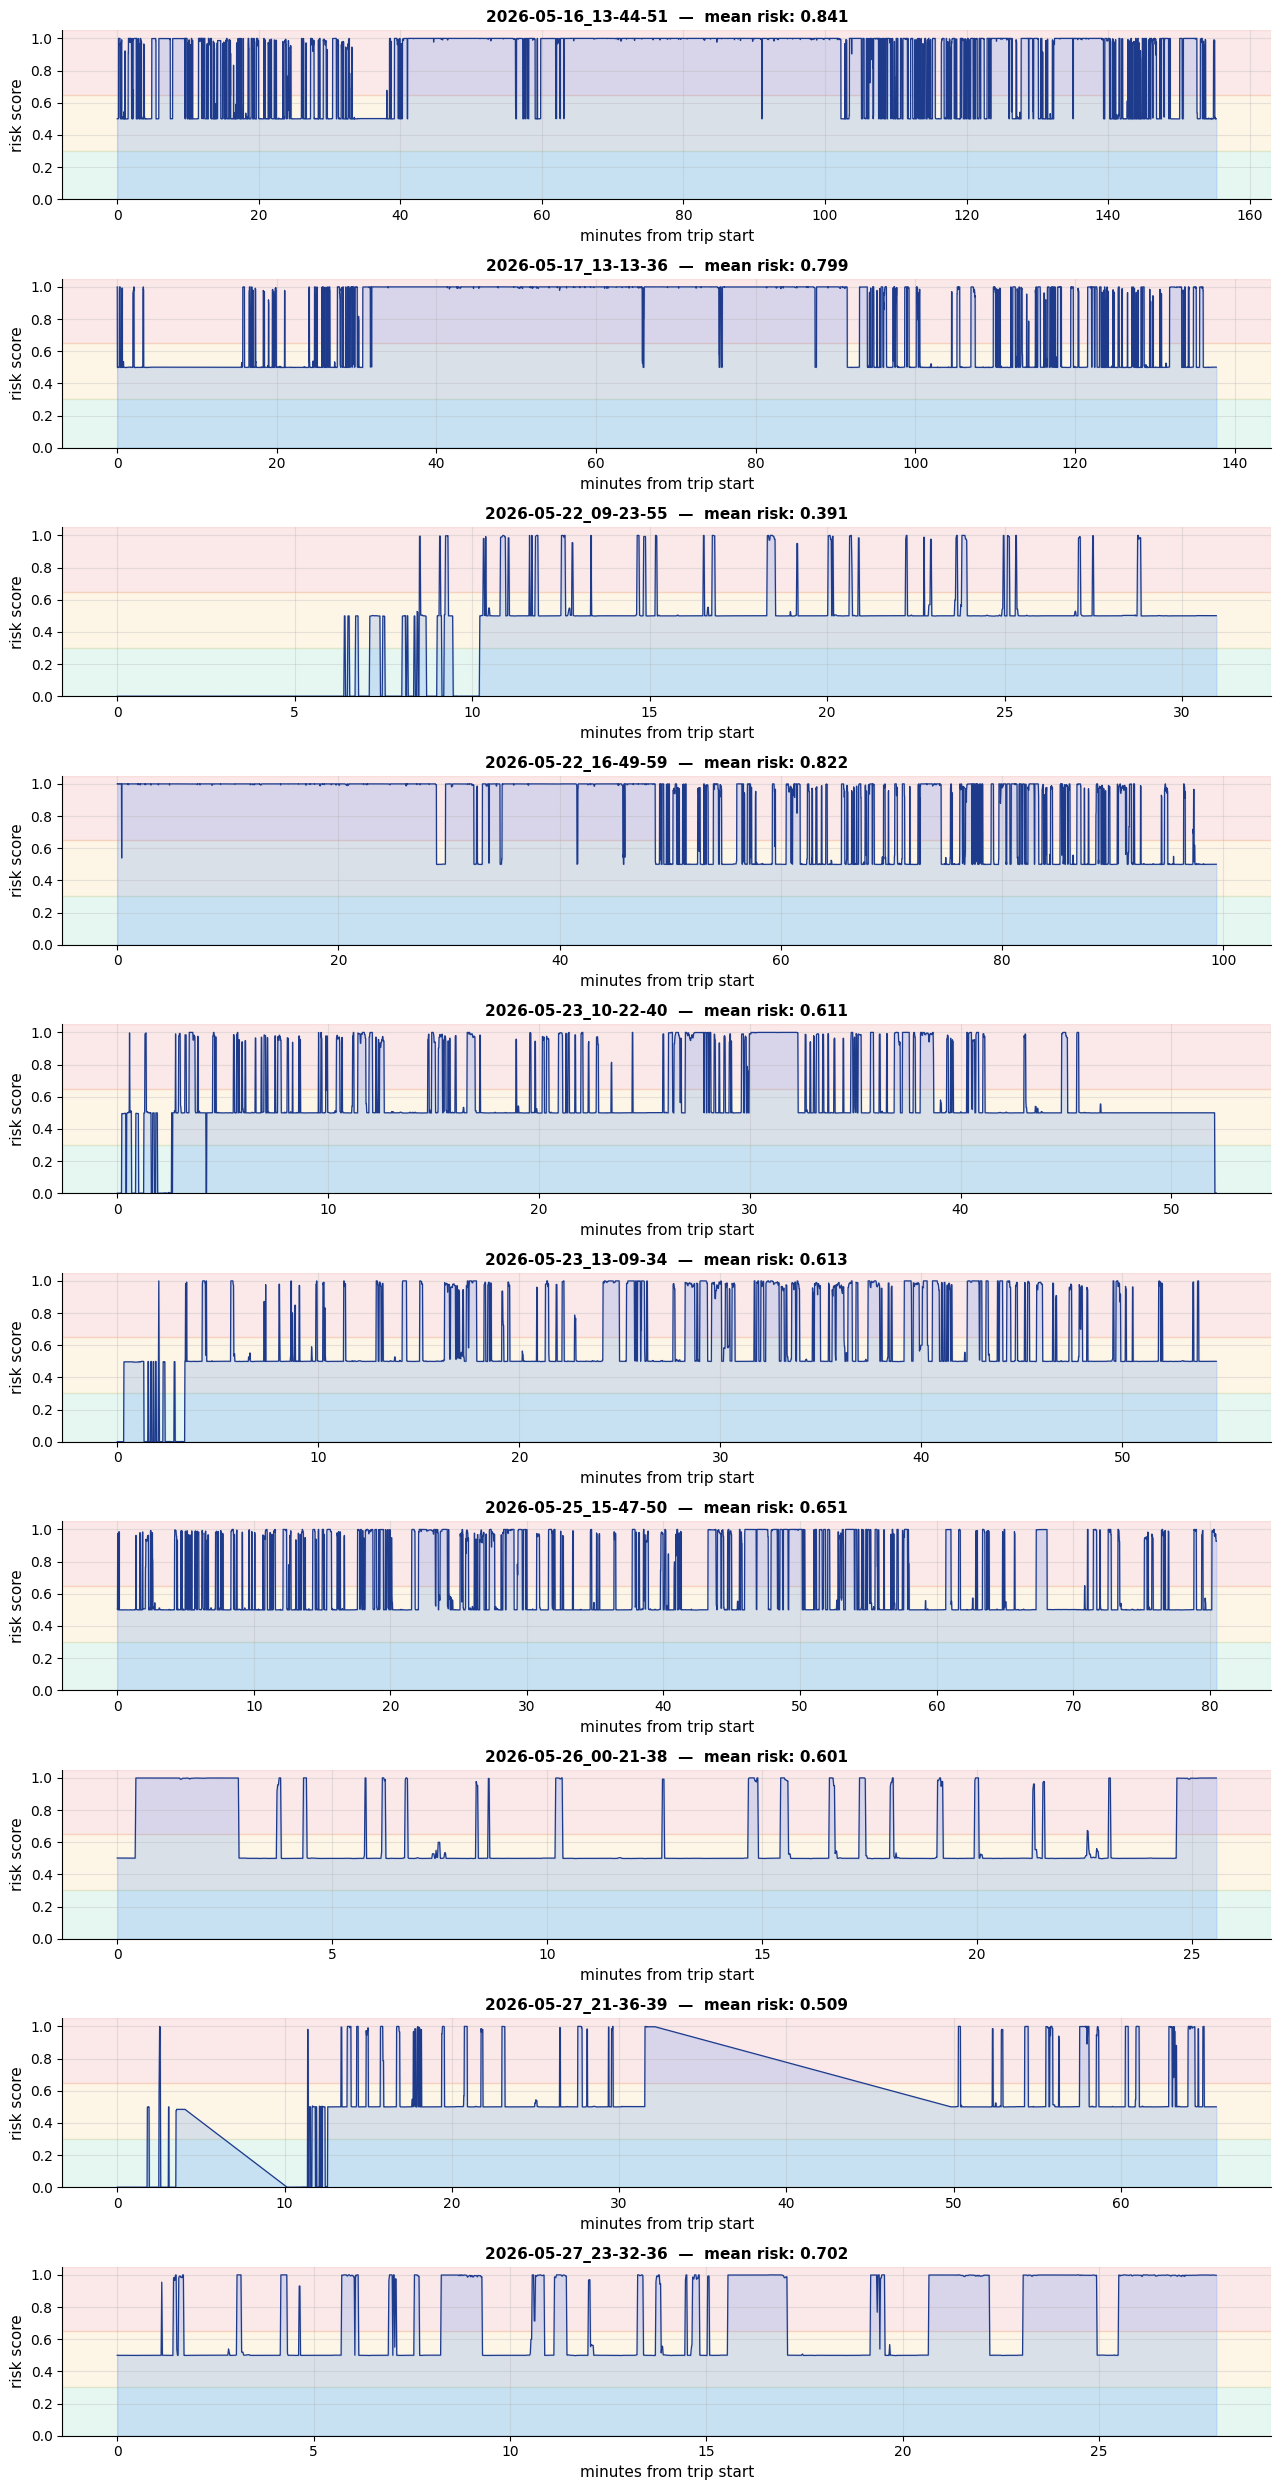

In [43]:
risk_rows = []
for trip_id, pred in predictions.items():
    if pred.empty:
        continue
    risk_rows.append({
        'trip_id':          trip_id,
        'n_scored':         len(pred),
        'risk_mean':        round(float(pred['risk'].mean()), 3),
        'risk_median':      round(float(pred['risk'].median()), 3),
        'risk_max':         round(float(pred['risk'].max()), 3),
        'pct_safe':         round((pred['verdict'] == 'safe').mean() * 100, 1),
        'pct_diagnostic':   round((pred['verdict'] == 'diagnostic').mean() * 100, 1),
        'pct_do_not_drive': round((pred['verdict'] == 'do_not_drive').mean() * 100, 1),
    })

risk_df = pd.DataFrame(risk_rows).set_index('trip_id') if risk_rows else pd.DataFrame()
print(f"Trip-level risk aggregation:\n")
print(risk_df.to_string())

if predictions:
    fig, axes = plt.subplots(len(predictions), 1, figsize=(13, 2.5 * len(predictions)), sharex=False)
    if len(predictions) == 1:
        axes = [axes]

    for ax, (trip_id, pred) in zip(axes, predictions.items()):
        if pred.empty:
            ax.text(0.5, 0.5, 'No predictions', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(trip_id, fontsize=11, fontweight='bold')
            continue

        t0_trip = pred.index.min()
        rel_min = (pred.index - t0_trip).total_seconds() / 60

        ax.axhspan(0.00, 0.30, color=VERDICT_COLORS[0], alpha=0.10, zorder=0)
        ax.axhspan(0.30, 0.65, color=VERDICT_COLORS[1], alpha=0.10, zorder=0)
        ax.axhspan(0.65, 1.05, color=VERDICT_COLORS[2], alpha=0.10, zorder=0)

        ax.plot(rel_min, pred['risk'], linewidth=0.9, color='#1e3a8a')
        ax.fill_between(rel_min, 0, pred['risk'], alpha=0.18, color='#3b82f6')

        ax.set_title(f"{trip_id}  —  mean risk: {pred['risk'].mean():.3f}",
                     fontsize=11, fontweight='bold')
        ax.set_ylabel('risk score')
        ax.set_xlabel('minutes from trip start')
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'plots' / 'field_03_risk_timeline.png', bbox_inches='tight', dpi=120)
    plt.show()

## Block 10 — Cross-trip distribution comparison

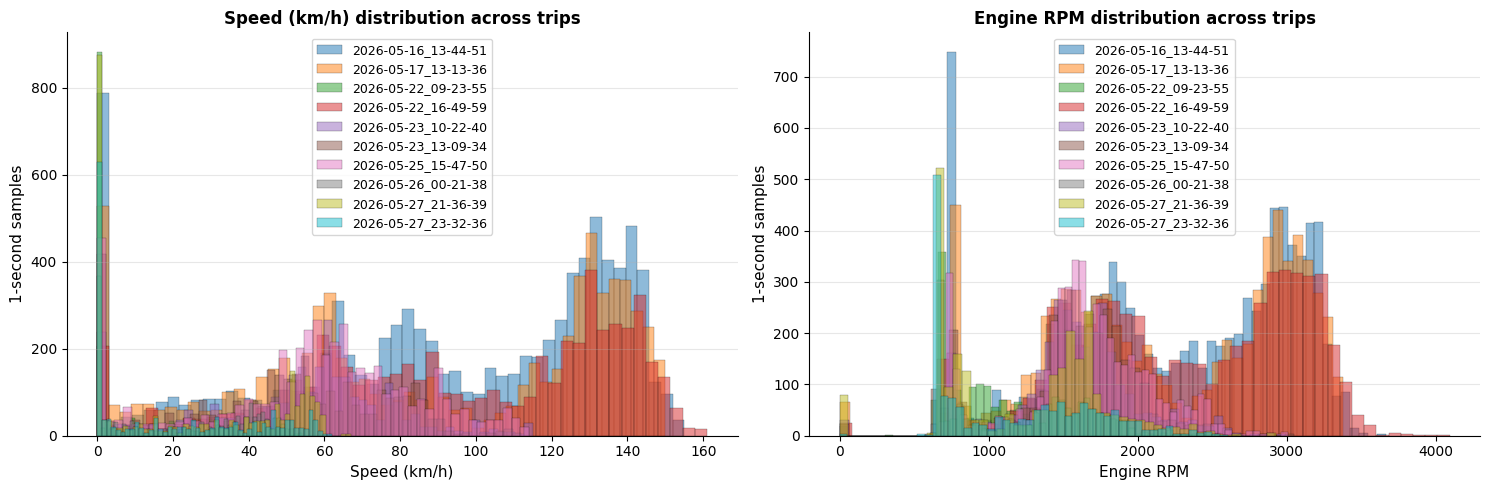

In [44]:
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, col, xlabel in zip(axes, ['SPEED', 'ENGINE_RPM'], ['Speed (km/h)', 'Engine RPM']):
    for i, (trip_id, df) in enumerate(trips_1hz.items()):
        if col in df.columns and df[col].notna().any():
            v = df[col].dropna()
            ax.hist(v, bins=50, alpha=0.5, label=trip_id,
                    color=colors[i % len(colors)], edgecolor='black', linewidth=0.3)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('1-second samples')
    ax.set_title(f'{xlabel} distribution across trips', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'field_04_speed_rpm_distributions.png', bbox_inches='tight', dpi=120)
plt.show()

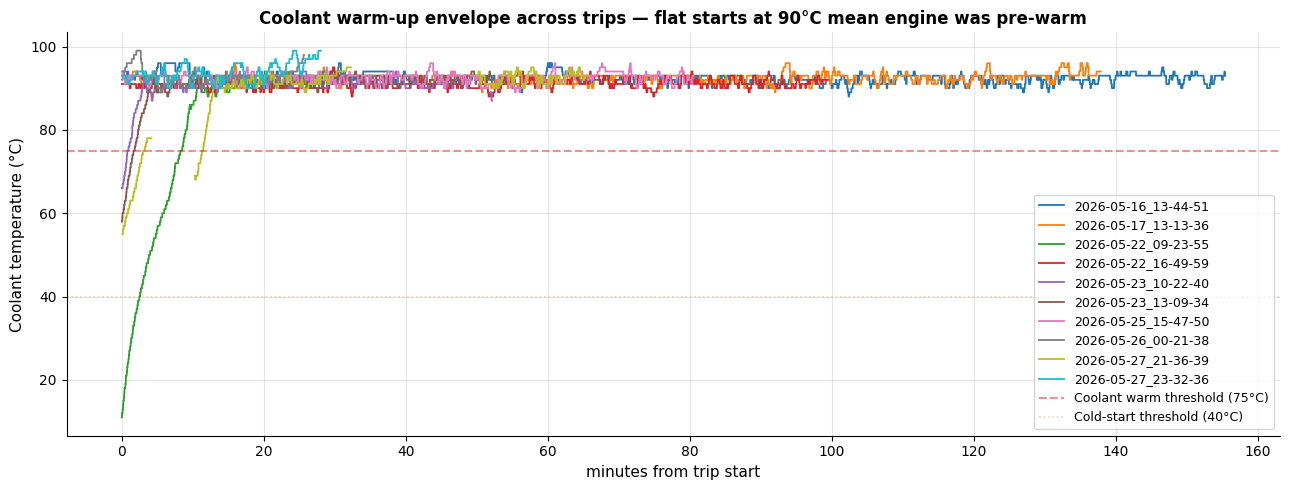

In [45]:
fig, ax = plt.subplots(figsize=(13, 5))
for i, (trip_id, df) in enumerate(trips_1hz.items()):
    if 'ENGINE_COOLANT_TEMP' in df.columns and df['ENGINE_COOLANT_TEMP'].notna().any():
        t0_trip = df.dropna(how='all').index.min()
        rel_min = (df.index - t0_trip).total_seconds() / 60
        ax.plot(rel_min, df['ENGINE_COOLANT_TEMP'], label=trip_id,
                linewidth=1.3, color=colors[i % len(colors)])

ax.axhline(75, color='#dc2626', linestyle='--', alpha=0.5, linewidth=1.5,
           label='Coolant warm threshold (75°C)')
ax.axhline(40, color='#fb923c', linestyle=':', alpha=0.4, linewidth=1.2,
           label='Cold-start threshold (40°C)')

ax.set_xlabel('minutes from trip start', fontsize=11)
ax.set_ylabel('Coolant temperature (°C)', fontsize=11)
ax.set_title('Coolant warm-up envelope across trips — '
             'flat starts at 90°C mean engine was pre-warm',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'plots' / 'field_05_coolant_warmup.png', bbox_inches='tight', dpi=120)
plt.show()

## Block 11 — Subjective vs predicted comparison

Subjective vs predicted (10 labeled trips):

                    subjective predicted_majority  pct_safe  pct_diagnostic  pct_do_not_drive  risk_mean
trip_id                                                                                                 
2026-05-16_13-44-51     normal       do_not_drive       0.0            31.5              68.5      0.841
2026-05-17_13-13-36     normal       do_not_drive       0.0            39.8              60.2      0.799
2026-05-22_09-23-55     normal         diagnostic      28.7            64.4               6.8      0.391
2026-05-22_16-49-59     normal       do_not_drive       0.0            35.2              64.8      0.822
2026-05-23_10-22-40     normal         diagnostic       3.4            70.3              26.3      0.611
2026-05-23_13-09-34     normal         diagnostic       3.7            69.2              27.2      0.613
2026-05-25_15-47-50     normal         diagnostic       0.0            69.1              30.9      0.651
2026-05-26

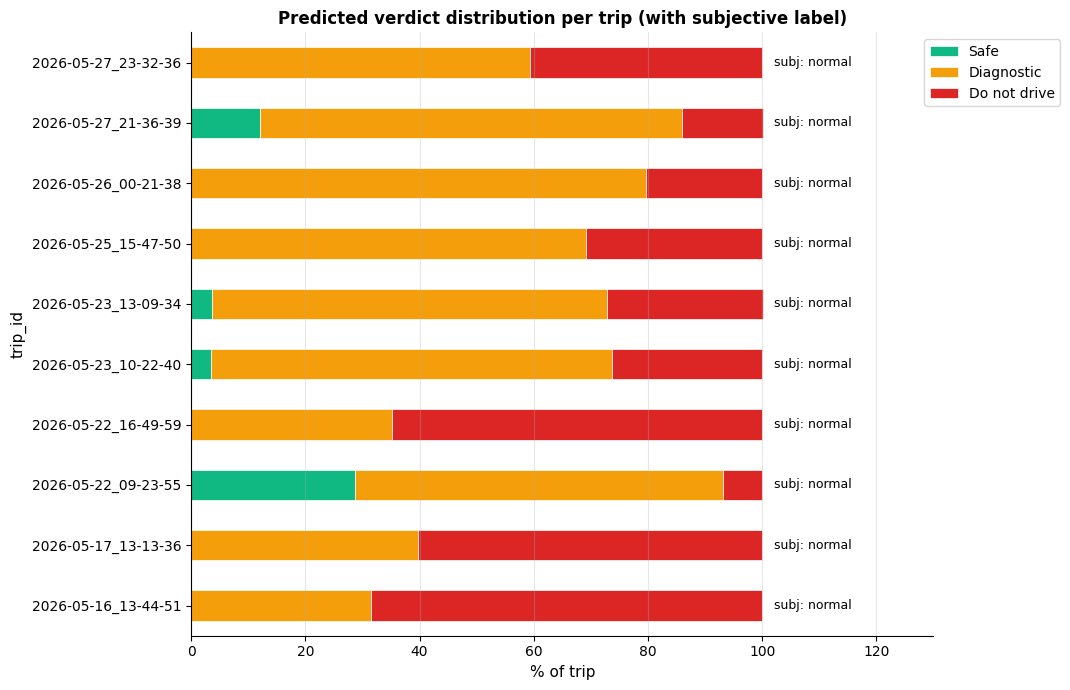

In [46]:
def trip_majority_verdict(pred):
    if pred.empty or 'verdict' not in pred.columns:
        return 'unknown'
    return str(pred['verdict'].value_counts().index[0])

cmp_rows = []
for trip_id, pred in predictions.items():
    meta = metadata[metadata['trip_id'] == trip_id]
    if meta.empty:
        continue
    subjective = str(meta.iloc[0].get('subjective', '')).strip()
    if not subjective or subjective in ('nan', ''):
        continue
    cmp_rows.append({
        'trip_id':              trip_id,
        'subjective':           subjective,
        'predicted_majority':   trip_majority_verdict(pred),
        'pct_safe':             round((pred['verdict'] == 'safe').mean() * 100, 1),
        'pct_diagnostic':       round((pred['verdict'] == 'diagnostic').mean() * 100, 1),
        'pct_do_not_drive':     round((pred['verdict'] == 'do_not_drive').mean() * 100, 1),
        'risk_mean':            round(float(pred['risk'].mean()), 3),
    })

comparison_df = pd.DataFrame(cmp_rows).set_index('trip_id') if cmp_rows else pd.DataFrame()

if not comparison_df.empty:
    print(f"Subjective vs predicted ({len(comparison_df)} labeled trips):\n")
    print(comparison_df.to_string())

    fig, ax = plt.subplots(figsize=(11, max(3, 0.5 * len(comparison_df) + 2)))
    plot_cols = ['pct_safe', 'pct_diagnostic', 'pct_do_not_drive']
    comparison_df[plot_cols].plot(
        kind='barh', stacked=True, ax=ax,
        color=VERDICT_COLORS, edgecolor='white', linewidth=0.5,
    )
    for i, (idx, row) in enumerate(comparison_df.iterrows()):
        ax.text(102, i, f"subj: {row['subjective']}", va='center', fontsize=9)
    ax.set_xlim(0, 130)
    ax.set_xlabel('% of trip')
    ax.set_title('Predicted verdict distribution per trip (with subjective label)',
                 fontsize=12, fontweight='bold')
    ax.legend(['Safe', 'Diagnostic', 'Do not drive'], loc='upper right', bbox_to_anchor=(1.18, 1))
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'plots' / 'field_06_subjective_vs_predicted.png',
                bbox_inches='tight', dpi=120)
    plt.show()
else:
    print(f"✗ No trips with subjective labels in metadata. Fill in trip_metadata.csv 'subjective' column.")

## Block 12 — Save artifacts

In [47]:
artifacts = {
    'subsystem': 'field_validation',
    'task':      'real-world validation of OBD-II stress detector on self-collected driving data',
    'dataset': {
        'name':              'self-collected via Vgate iCar Pro BLE 4.0 + Car Scanner Pro (iOS)',
        'vehicles':          metadata['vehicle'].dropna().unique().tolist() if not metadata.empty else [],
        'drivers':           metadata['driver'].dropna().unique().tolist() if not metadata.empty else [],
        'n_trips':           int(len(trips_1hz)),
        'total_samples_1hz': int(sum(len(d) for d in trips_1hz.values())),
        'total_duration_min': round(float(sum(
            (d.dropna(how='all').index.max() - d.dropna(how='all').index.min()).total_seconds() / 60
            for d in trips_1hz.values()
        )), 1),
    },
    'pipeline': {
        'parser':       'Russian column names → standardized PIDs via COLUMN_MAP',
        'resampling':   '1 Hz grid via last-in-bucket, ffill capped at 30s',
        'inference':    f'ONNX OBD-II stress model on {len(ONNX_FEATURES)} features',
        'risk_score':   '0.5 × P(Diagnostic) + 1.0 × P(Critical)',
        'thresholds':   {'safe': '< 0.30', 'diagnostic': '0.30–0.65', 'do_not_drive': '> 0.65'},
    },
    'model': {
        'onnx_path':     str(ONNX_PATH.relative_to(PROJECT_ROOT)),
        'feature_order': ONNX_FEATURES,
    },
    'trip_summary':            summary_df.reset_index().to_dict(orient='records'),
    'conditions_breakdown':    cond_df.reset_index().to_dict(orient='records'),
    'risk_per_trip':           risk_df.reset_index().to_dict(orient='records') if not risk_df.empty else [],
    'subjective_vs_predicted': comparison_df.reset_index().to_dict(orient='records') if not comparison_df.empty else [],
    'generated_at':            datetime.utcnow().isoformat() + 'Z',
}

artifacts_path = OUTPUTS_DIR / 'data' / 'field_validation_results.json'
with open(artifacts_path, 'w', encoding='utf-8') as f:
    json.dump(artifacts, f, indent=2, ensure_ascii=False, default=str)

summary_csv_path = OUTPUTS_DIR / 'data' / 'field_trip_summary.csv'
summary_df.to_csv(summary_csv_path)

print(f"JSON:  {artifacts_path.relative_to(PROJECT_ROOT)}  ({artifacts_path.stat().st_size / 1024:.1f} KB)")
print(f"CSV:   {summary_csv_path.relative_to(PROJECT_ROOT)}  ({summary_csv_path.stat().st_size / 1024:.1f} KB)")
print(f"\nField validation summary:")
print(f"  Trips:               {artifacts['dataset']['n_trips']}")
print(f"  Total samples (1Hz): {artifacts['dataset']['total_samples_1hz']:,}")
print(f"  Total duration:      {artifacts['dataset']['total_duration_min']:.0f} min "
      f"({artifacts['dataset']['total_duration_min']/60:.1f} h)")
print(f"  Drivers:             {artifacts['dataset']['drivers']}")
print(f"  Vehicles:            {artifacts['dataset']['vehicles']}")

JSON:  outputs\data\field_validation_results.json  (12.3 KB)
CSV:   outputs\data\field_trip_summary.csv  (1.1 KB)

Field validation summary:
  Trips:               10
  Total samples (1Hz): 43,869
  Total duration:      731 min (12.2 h)
  Drivers:             ['']
  Vehicles:            ['Hyundai Tucson']


## Block 13 — Auto-deploy artifacts to dashboard

In [48]:
import shutil

DASHBOARD_PLOTS = PROJECT_ROOT / 'dashboard' / 'assets' / 'plots'
DASHBOARD_DATA  = PROJECT_ROOT / 'dashboard' / 'assets' / 'data'
DASHBOARD_PLOTS.mkdir(parents=True, exist_ok=True)
DASHBOARD_DATA.mkdir(parents=True, exist_ok=True)

plots_copied = 0
for plot in sorted((OUTPUTS_DIR / 'plots').glob('field_*.png')):
    shutil.copy2(plot, DASHBOARD_PLOTS / plot.name)
    plots_copied += 1

shutil.copy2(artifacts_path,   DASHBOARD_DATA / 'field_validation_results.json')
shutil.copy2(summary_csv_path, DASHBOARD_DATA / 'field_trip_summary.csv')

print(f"✓ Deployed to dashboard:")
print(f"  {plots_copied} plot(s)  →  {DASHBOARD_PLOTS.relative_to(PROJECT_ROOT)}")
print(f"  field_validation_results.json  →  {DASHBOARD_DATA.relative_to(PROJECT_ROOT)}")
print(f"  field_trip_summary.csv  →  {DASHBOARD_DATA.relative_to(PROJECT_ROOT)}")

✓ Deployed to dashboard:
  6 plot(s)  →  dashboard\assets\plots
  field_validation_results.json  →  dashboard\assets\data
  field_trip_summary.csv  →  dashboard\assets\data
